In [1]:
# CELL 1 — Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model

from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
# CELL 2 — Load EfficientNet Model
model = load_model(
    "../models/efficientnet_final.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


Selected: 407d9731-c2d8-48c1-8712-9719c185791c___RS_Erly.B 9496.JPG


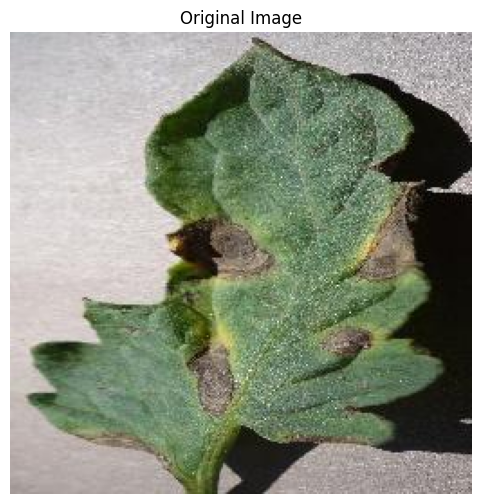

In [3]:
# CELL 3 — Select Image

import os
import random

folder = "../dataset/disease/Tomato_Early_blight"

image_file = random.choice(
    os.listdir(folder)
)

image_path = os.path.join(
    folder,
    image_file
)

print("Selected:", image_file)

img = cv2.imread(image_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [4]:
# CELL 4 — Preprocess Image
IMG_SIZE = 224

img_resized = cv2.resize(
    img,
    (IMG_SIZE, IMG_SIZE)
)

input_image = img_resized.astype(
    np.float32
)

input_image = np.expand_dims(
    input_image,
    axis=0
)

In [5]:
# CELL 5 — Predict Disease
predictions = model.predict(
    input_image
)

class_names = [

    "Tomato_Early_blight",

    "Tomato_Late_blight",

    "Tomato_Leaf_Mold",

    "Tomato_healthy"
]

predicted_class = np.argmax(
    predictions
)

confidence = np.max(
    predictions
)

print(
    "Prediction:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    round(confidence*100,2),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tomato_Early_blight
Confidence: 99.99 %


In [6]:
# CELL 6 — Find Last Convolution Layer

for layer in model.layers:
    print(layer.name)

input_layer_5
sequential_1
efficientnetb0
global_average_pooling2d_2
batch_normalization
dense_4
dropout_2
dense_5


In [9]:
base_model = model.get_layer("efficientnetb0")

for layer in base_model.layers[-20:]:
    print(layer.name)

block6d_project_conv
block6d_project_bn
block6d_drop
block6d_add
block7a_expand_conv
block7a_expand_bn
block7a_expand_activation
block7a_dwconv
block7a_bn
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [10]:
base_model = model.get_layer("efficientnetb0")

print(base_model.layers[-1].name)

top_activation


In [11]:
for layer in reversed(base_model.layers):
    print(layer.name)
    if "conv" in layer.name:
        break

top_activation
top_bn
top_conv


In [12]:
# CELL 7 — Grad-CAM Function
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
):

    base_model = model.get_layer("efficientnetb0")

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0
    ) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [14]:
heatmap = make_gradcam_heatmap(
    input_image,
    model,
    "top_conv"
)

plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

ValueError: Output with path `0` is not connected to `inputs`

In [15]:
print(model.name)

for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

functional_4
0 input_layer_5 InputLayer
1 sequential_1 Sequential
2 efficientnetb0 Functional
3 global_average_pooling2d_2 GlobalAveragePooling2D
4 batch_normalization BatchNormalization
5 dense_4 Dense
6 dropout_2 Dropout
7 dense_5 Dense


In [16]:
base_model = model.get_layer("efficientnetb0")

print(base_model.input)
print(base_model.output)

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_4>
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_508>


In [18]:
base_model = model.get_layer("efficientnetb0")

for layer in base_model.layers[-10:]:
    print(layer.name)

last_conv_layer = base_model.get_layer("top_conv")

print(last_conv_layer.output.shape)

block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation
(None, 7, 7, 1280)


In [19]:
grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[
        last_conv_layer.output,
        model.output
    ]
)
print("Grad Model Created")

ValueError: Output with path `0` is not connected to `inputs`

In [20]:
print("Model Input:")
print(model.input)

print("\nModel Output:")
print(model.output)

print("\nEfficientNet Layer:")
base_model = model.get_layer("efficientnetb0")

print(base_model)

print("\nEfficientNet Input:")
print(base_model.input)

print("\nEfficientNet Output:")
print(base_model.output)

Model Input:
<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_5>

Model Output:
<KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_522>

EfficientNet Layer:
<Functional name=efficientnetb0, built=True>

EfficientNet Input:
<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_4>

EfficientNet Output:
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_508>


In [21]:
base_model = model.get_layer("efficientnetb0")

for layer in base_model.layers[-20:]:
    print(layer.name, layer.output.shape)

block6d_project_conv (None, 7, 7, 192)
block6d_project_bn (None, 7, 7, 192)
block6d_drop (None, 7, 7, 192)
block6d_add (None, 7, 7, 192)
block7a_expand_conv (None, 7, 7, 1152)
block7a_expand_bn (None, 7, 7, 1152)
block7a_expand_activation (None, 7, 7, 1152)
block7a_dwconv (None, 7, 7, 1152)
block7a_bn (None, 7, 7, 1152)
block7a_activation (None, 7, 7, 1152)
block7a_se_squeeze (None, 1152)
block7a_se_reshape (None, 1, 1, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_expand (None, 1, 1, 1152)
block7a_se_excite (None, 7, 7, 1152)
block7a_project_conv (None, 7, 7, 320)
block7a_project_bn (None, 7, 7, 320)
top_conv (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_activation (None, 7, 7, 1280)


In [22]:
print(type(model))
print(type(base_model))

<class 'keras.src.models.functional.Functional'>
<class 'keras.src.models.functional.Functional'>


In [23]:
base_model = model.get_layer("efficientnetb0")

classifier = tf.keras.Sequential([
    model.layers[3],  # GlobalAveragePooling2D
    model.layers[4],  # BatchNormalization
    model.layers[5],  # Dense
    model.layers[6],  # Dropout
    model.layers[7]   # Dense(4)
])

print("Classifier Created")

Classifier Created


In [24]:
def make_gradcam_heatmap(img_array):

    base_model = model.get_layer("efficientnetb0")

    last_conv_layer = base_model.get_layer("top_conv")

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, features = grad_model(img_array)

        tape.watch(conv_outputs)

        predictions = classifier(features)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

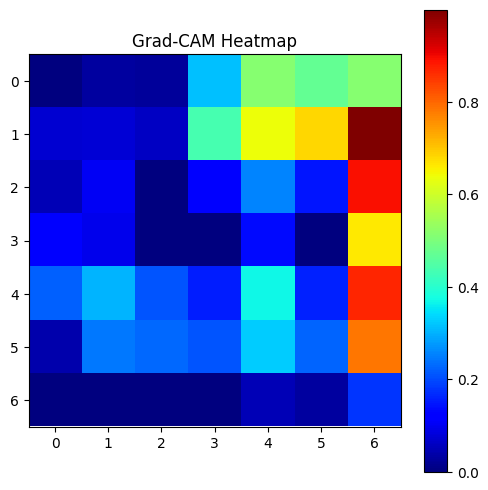

In [25]:
heatmap = make_gradcam_heatmap(
    input_image
)

plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()